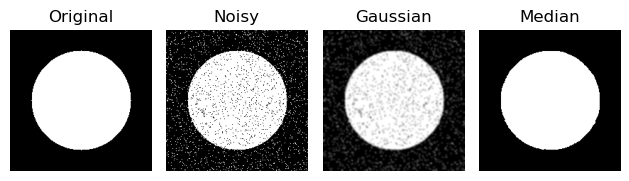

Gaussian PSNR: 31.73
Median PSNR: 76.67


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Create simple image
img = np.zeros((200, 200), dtype=np.uint8)
cv2.circle(img, (100, 100), 70, 255, -1)

# Add salt & pepper noise
noisy = img.copy()
noise = np.random.random(img.shape)
noisy[noise < 0.05] = 0
noisy[noise > 0.95] = 255

# Apply filters
gaussian = cv2.GaussianBlur(noisy, (5, 5), 0)
median = cv2.medianBlur(noisy, 5)

# Display
titles = ['Original', 'Noisy', 'Gaussian', 'Median']
images = [img, noisy, gaussian, median]

for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

# PSNR
def psnr(a, b):
    mse = np.mean((a - b) ** 2)
    return 20 * np.log10(255.0 / np.sqrt(mse)) if mse else float('inf')

print("Gaussian PSNR:", round(psnr(img, gaussian), 2))
print("Median PSNR:", round(psnr(img, median), 2))